In [23]:
# Soft pastel colors
colors = [
    "#A3C1AD",  # pastel green
    "#FFB7B2",  # pastel pink
    "#FFDAC1",  # pastel orange
    "#C7CEEA",  # pastel purple
    "#F3EAC2",  # pastel yellow
    "#B5EAD7",  # pastel mint
    "#FF9AA2",  # soft coral
    "#D5AAFF",  # pastel violet
    "#FFDFBA",  # pastel peach
    "#C1E1C1",  # light green
]


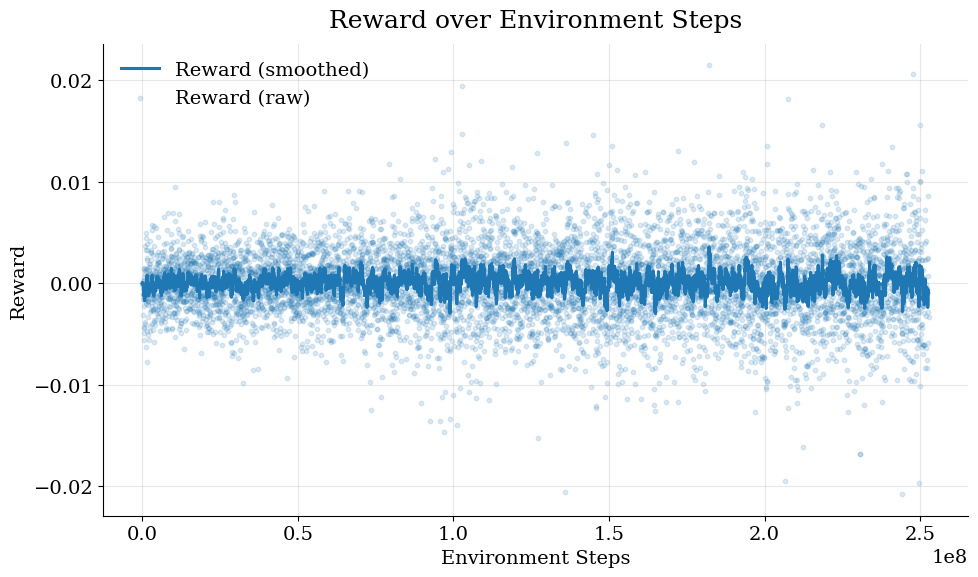

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Settings for beautiful plots
# -----------------------------
plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",
    "figure.figsize": (10, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300
})

# -----------------------------
# Load CSV exported from W&B
# -----------------------------
csv_path = "wandb_export_2025-11-16T19_18_41.477+01_00.csv"   # <--- change to your file
df = pd.read_csv(csv_path)

# Typical W&B fields: 'global_step', 'train/reward', 'reward', or similar
# Adjust names here depending on your file:
step_col = "train/env_steps"   # or "env_step", "step", etc.
reward_col = "encoder_reward_method: mean_baseline_adjusted - train/encoder_punishment"      # or "train/reward", "eval/reward"

# Drop NaNs to avoid gaps
df = df[[step_col, reward_col]].dropna()

# -----------------------------
# Optional smoothing
# -----------------------------
def smooth(x, weight=0.9):
    """Exponential moving average smoothing."""
    smoothed = []
    last = x[0]
    for val in x:
        smoothed_val = last * weight + (1 - weight) * val
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

df["reward_smooth"] = smooth(df[reward_col].values, weight=0.9)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots()

ax.plot(df[step_col], df["reward_smooth"], color="#1f77b4",
        label="Reward (smoothed)")

# Also plot raw data lightly
ax.scatter(df[step_col], df[reward_col], color="#1f77b4",
           alpha=0.15, s=10, label="Reward (raw)")

# Titles & labels
ax.set_title("Reward over Environment Steps", fontsize=18, pad=12)
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Reward")

ax.legend(frameon=False)

plt.tight_layout()
plt.show()


train/env_steps	encoder_reward_method: baseline_adjusted - _step	encoder_reward_method: baseline_adjusted - _step__MIN	encoder_reward_method: baseline_adjusted - _step__MAX	encoder_reward_method: baseline_adjusted - train/encoder_punishment	encoder_reward_method: baseline_adjusted - train/encoder_punishment__MIN	encoder_reward_method: baseline_adjusted - train/encoder_punishment__MAX	encoder_reward_method: mean_baseline_adjusted - _step	encoder_reward_method: mean_baseline_adjusted - _step__MIN	encoder_reward_method: mean_baseline_adjusted - _step__MAX	encoder_reward_method: mean_baseline_adjusted - train/encoder_punishment	encoder_reward_method: mean_baseline_adjusted - train/encoder_punishment__MIN	encoder_reward_method: mean_baseline_adjusted - train/encoder_punishment__MAX	encoder_reward_method: punish - _step	encoder_reward_method: punish - _step__MIN	encoder_reward_method: punish - _step__MAX	encoder_reward_method: punish - train/encoder_punishment	encoder_reward_method: punish - train/encoder_punishment__MIN	encoder_reward_method: punish - train/encoder_punishment__MAX


/tmp/ipykernel_583994/2978239512.py:79: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.82, 1])  # leave space on the right


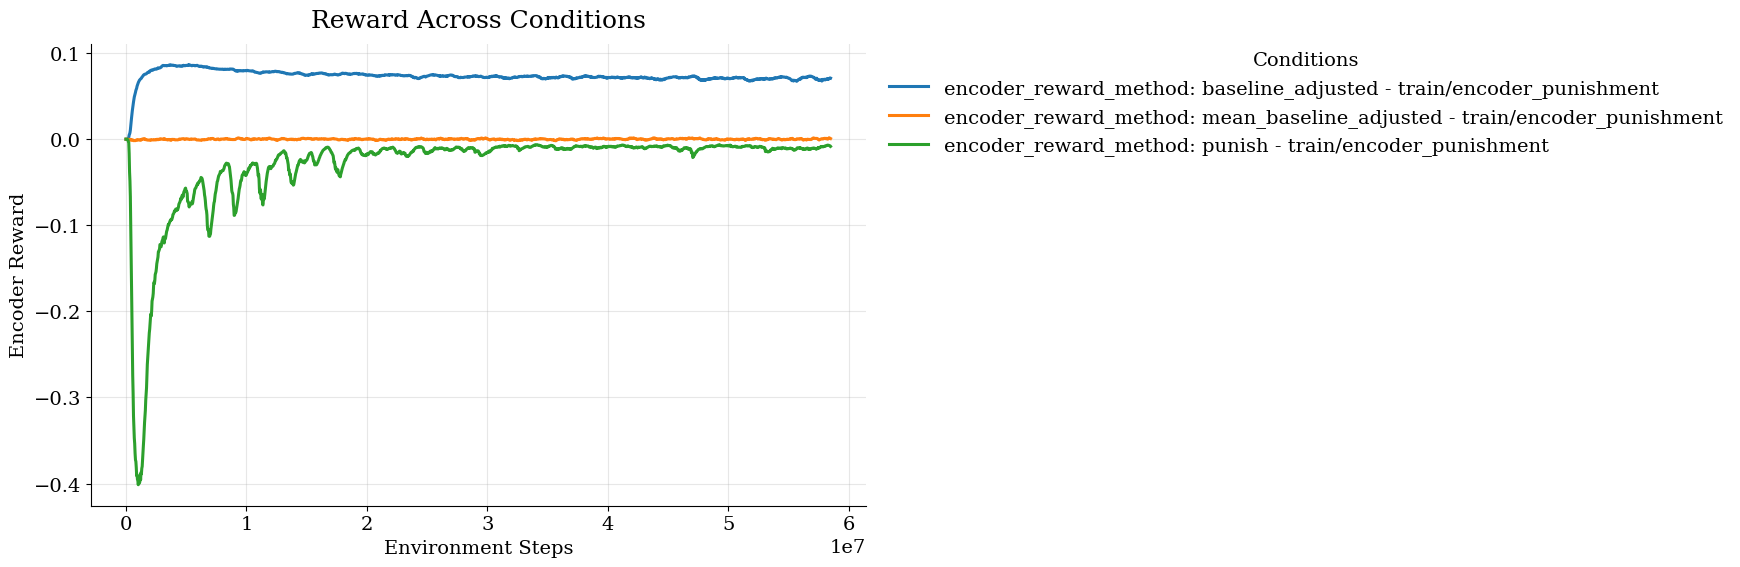

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# BEAUTIFUL STYLE SETTINGS
# -----------------------------
# plt.rcParams.update({
#     "font.size": 14,
#     "font.family": "serif",
#     "figure.figsize": (10, 6),
#     "axes.spines.top": False,
#     "axes.spines.right": False,
#     "axes.grid": True,
#     "grid.alpha": 0.3,
#     "lines.linewidth": 2.2,
#     "savefig.dpi": 300,
# })

# -----------------------------
# Load CSV
# -----------------------------
csv_path = "wandb_export_2025-11-16T19_18_41.477+01_00.csv"   # change this
df = pd.read_csv(csv_path)

# Choose which columns represent conditions
# (modify these to match your CSV)
step_col = "train/env_steps"
reward_columns = [
    "encoder_reward_method: baseline_adjusted - train/encoder_punishment",
    "encoder_reward_method: mean_baseline_adjusted - train/encoder_punishment",
    "encoder_reward_method: punish - train/encoder_punishment"
]

# Drop NaNs
df = df[[step_col] + reward_columns].dropna()

df = df.iloc[: int(len(df) * 0.25)]


# -----------------------------
# OPTIONAL: smoothing helper
# -----------------------------
def smooth(x, weight=0.9):
    smoothed = []
    last = x[0]
    for val in x:
        smoothed_val = last * weight + (1 - weight) * val
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots()

colors = plt.cm.tab10.colors  # nice qualitative palette

for i, col in enumerate(reward_columns):
    smoothed = smooth(df[col].values, weight=0.9)
    ax.plot(df[step_col], smoothed, label=col, color=colors[i % len(colors)])

# Titles & labels
ax.set_title("Reward Across Conditions", fontsize=18, pad=12)
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Encoder Reward")

# -----------------------------
# Legend outside the figure
# -----------------------------
ax.legend(
    title="Conditions",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout(rect=[0, 0, 0.82, 1])  # leave space on the right
plt.show()


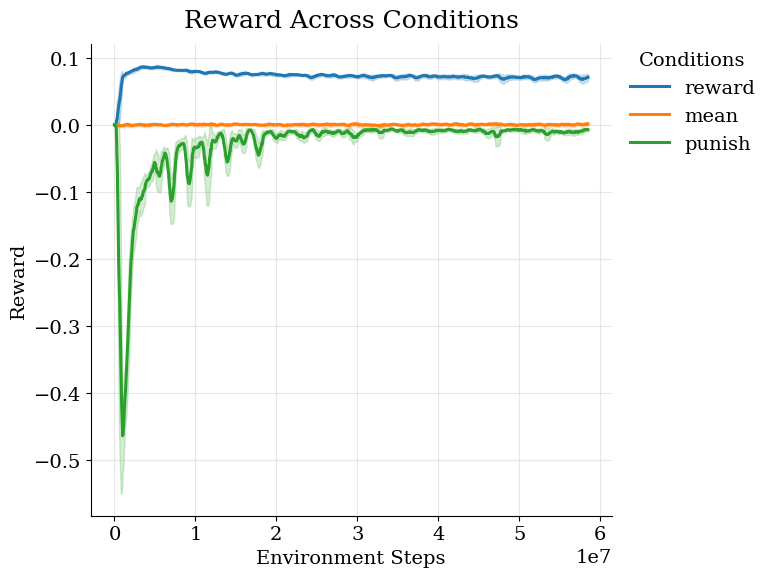

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# BEAUTIFUL STYLE
# ------------------------------------------
plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",
    "figure.figsize": (10, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
})

# ------------------------------------------
# Load data
# ------------------------------------------
csv_path = "wandb_export_2025-11-16T19_18_41.477+01_00.csv"   # change this
df = pd.read_csv(csv_path)

# Choose which columns represent conditions
# (modify these to match your CSV)
step_col = "train/env_steps"
reward_columns = [
    "encoder_reward_method: baseline_adjusted - train/encoder_punishment",
    "encoder_reward_method: mean_baseline_adjusted - train/encoder_punishment",
    "encoder_reward_method: punish - train/encoder_punishment"
]

# Keep only needed data
df = df[[step_col] + reward_columns].dropna()
df = df.iloc[: int(len(df) * 0.25)]

# Optional: only first 25% of data
# df = df.iloc[: int(len(df) * 0.25)]

# ------------------------------------------
# Smoothing function: rolling mean + std
# ------------------------------------------
def rolling_stats(series, window=50):
    """Return rolling mean and std."""
    mean = series.rolling(window=window, min_periods=1).mean()
    std = series.rolling(window=window, min_periods=1).std()
    return mean, std

# ------------------------------------------
# Plot
# ------------------------------------------
fig, ax = plt.subplots()
colors = plt.cm.tab10.colors

# Custom legend names (optional)
legend_names = {
    "encoder_reward_method: baseline_adjusted - train/encoder_punishment": "reward",
    "encoder_reward_method: mean_baseline_adjusted - train/encoder_punishment": "mean",
    "encoder_reward_method: punish - train/encoder_punishment": "punish"
}

for i, col in enumerate(reward_columns):
    color = colors[i % len(colors)]

    # Compute rolling mean + std
    mean, std = rolling_stats(df[col], window=20)

    # Plot smooth curve
    ax.plot(
        df[step_col],
        mean,
        color=color,
        label=legend_names.get(col, col)
    )

    # Plot std shading
    ax.fill_between(
        df[step_col],
        mean - std,
        mean + std,
        color=color,
        alpha=0.20
    )

# Titles & labels
ax.set_title("Reward Across Conditions", fontsize=18, pad=12)
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Reward")

# Legend outside
ax.legend(
    title="Conditions",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout(rect=[0, 0, 0.80, 1])  # leave room for legend
plt.show()


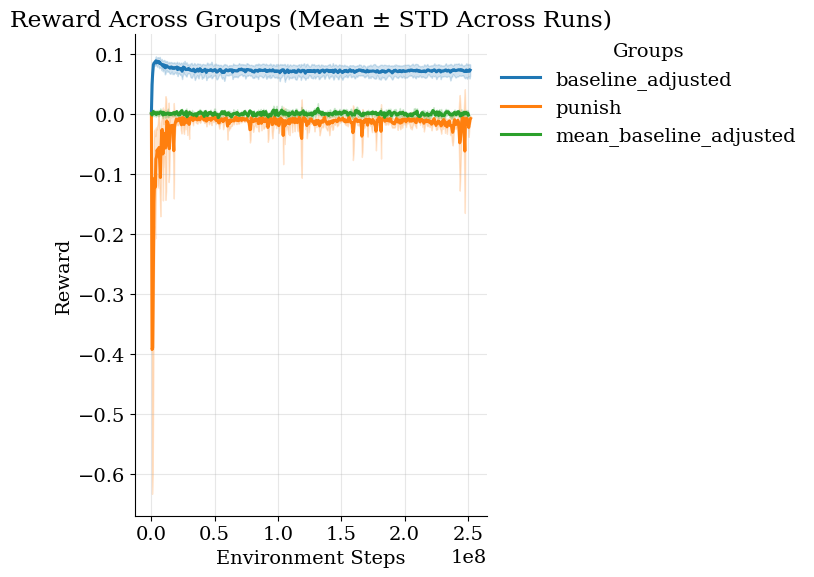

In [18]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

api = wandb.Api()

project = "xiaoxionglin-bernstein-center-freiburg/SF_distanceMetric_seperateReward3DG"
group_key = "encoder_reward_method" 
groups = ['baseline_adjusted', 'punish', 'mean_baseline_adjusted']   # Your W&B run groups
metric = "train/encoder_punishment"                      # Metric inside each run
step_col = "train/env_steps"

# --------------------------------------
# BEAUTIFUL STYLE
# --------------------------------------
plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",
    "figure.figsize": (10, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300
})

fig, ax = plt.subplots()
colors = plt.cm.tab10.colors

# --------------------------------------
# Helper: resample runs to common steps
# --------------------------------------
def resample_run(df, step_col, metric, num_points=500):
    df = df[[step_col, metric]].dropna()
    steps = np.linspace(df[step_col].min(), df[step_col].max(), num_points)
    values = np.interp(steps, df[step_col], df[metric])
    return steps, values

# --------------------------------------
# Loop over groups
# --------------------------------------
for gi, group_name in enumerate(groups):
    color = colors[gi % len(colors)]

    # fetch runs from group
    runs = api.runs(
    project,
    filters={f"config.{group_key}": group_name}
    )


    resampled = []

    # resample each run to same x-axis
    for run in runs:
        df = run.history(keys=[metric, step_col])
        if len(df) < 10:
            continue
        steps, values = resample_run(df, step_col, metric)
        resampled.append(values)

    if not resampled:
        continue

    # convert to array: shape (num_runs, num_steps)
    resampled = np.array(resampled)

    # compute group mean + std
    mean = resampled.mean(axis=0)
    std = resampled.std(axis=0)

    # plot smooth mean
    ax.plot(steps, mean, color=color, label=group_name)

    # shaded std region
    ax.fill_between(
        steps,
        mean - std,
        mean + std,
        color=color,
        alpha=0.20
    )

# --------------------------------------
# Legend outside
# --------------------------------------
ax.legend(
    title="Groups",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

ax.set_title("Reward Across Groups (Mean ± STD Across Runs)")
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Reward")

plt.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()


In [14]:
project = api.runs("xiaoxionglin-bernstein-center-freiburg/SF_distanceMetric_seperateReward3DG")
print(set(run.group for run in project))

{'openfield_map2_fixed_loc3_noreward'}


In [20]:
project = api.runs("xiaoxionglin-bernstein-center-freiburg/SF_distanceMetric_seperateReward3DG")

algos = list(set(run.config.get("encoder_reward_method") for run in project))
print(algos)


['baseline_adjusted', 'punish', 'mean_baseline_adjusted']


Detected groups: ['baseline_adjusted', 'mean_baseline_adjusted', 'punish']


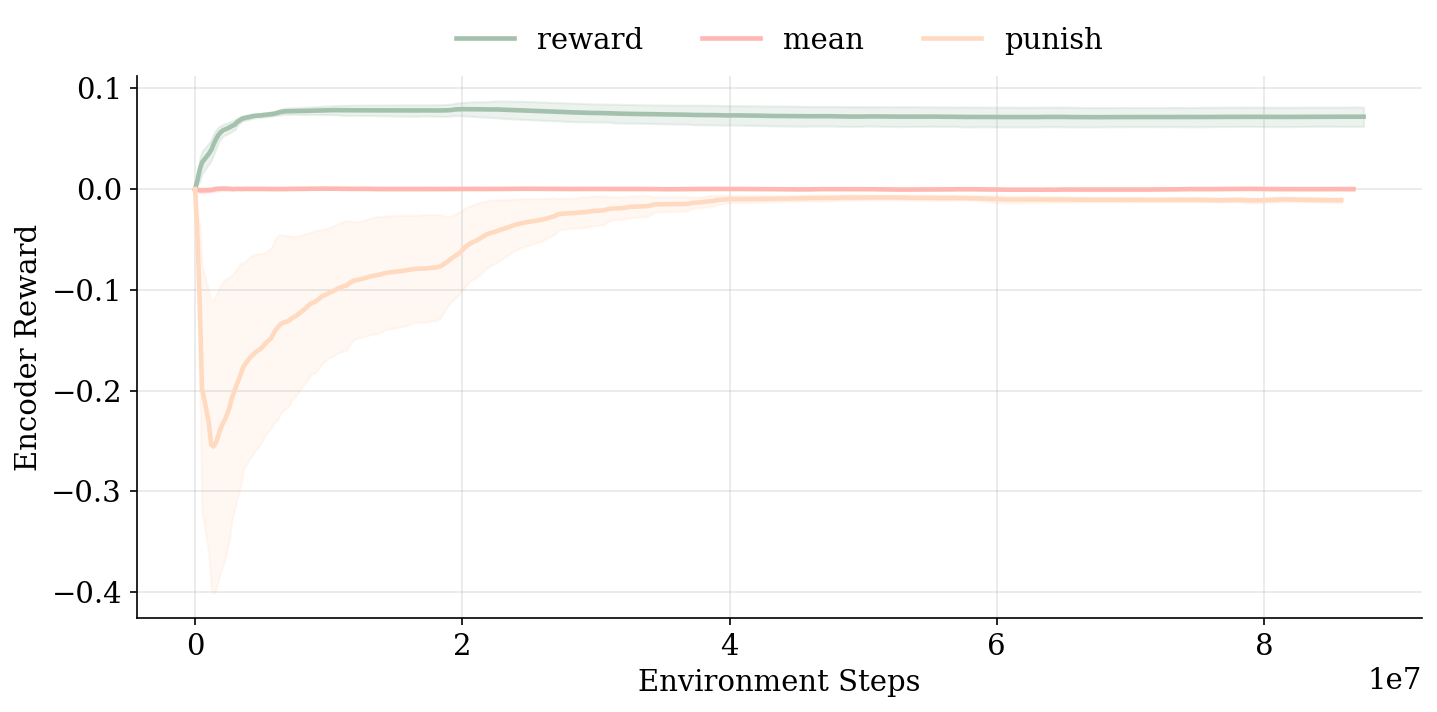

In [43]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# USER SETTINGS
# --------------------------
project_name = "xiaoxionglin-bernstein-center-freiburg/SF_distanceMetric_seperateReward3DG"   # Replace with your project
group_key = "encoder_reward_method"              # Config parameter to group runs by
metric = "train/encoder_punishment"               # Metric to plot
step_col = "train/env_steps"              # Step column in W&B
n_frac = 0.35                   # Keep first 25% of data
smooth_window = 50              # Rolling mean window

# --------------------------
# BEAUTIFUL PLOTTING STYLE
# --------------------------
plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",
    "figure.figsize": (10, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300
})

# --------------------------
# Initialize W&B API
# --------------------------
api = wandb.Api()

# Get all runs
all_runs = api.runs(project_name)

# Detect all group values for the chosen config key
groups = sorted(set(run.config.get(group_key) for run in all_runs if run.config.get(group_key) is not None))
print("Detected groups:", groups)

# --------------------------
# Smoothing function
# --------------------------
def rolling_smooth(series, window=50):
    return series.rolling(window=window, min_periods=1).mean()

# --------------------------
# Plot
# --------------------------
fig, ax = plt.subplots(1, 1, figsize=(10,5), dpi=150)
# colors = plt.cm.tab10.colors

for gi, group_name in enumerate(groups):
    color = colors[gi % len(colors)]
    
    # Fetch runs for this group
    runs = api.runs(project_name, filters={f"config.{group_key}": group_name})
    resampled_runs = []

    for run in runs:
        df = run.history(keys=[metric, step_col]).dropna()
        if len(df) < 10:
            continue
        
        # Keep only first n% of steps
        max_step = df[step_col].max()
        df = df[df[step_col] <= max_step * n_frac]
        if len(df) < 5:
            continue
        
        # Smooth
        df[metric + "_smooth"] = rolling_smooth(df[metric], window=smooth_window)

        # Resample to common axis
        num_points = 500
        steps = np.linspace(df[step_col].min(), df[step_col].max(), num_points)
        values = np.interp(steps, df[step_col], df[metric + "_smooth"])
        resampled_runs.append(values)

    if not resampled_runs:
        continue

    resampled_runs = np.array(resampled_runs)
    mean_curve = resampled_runs.mean(axis=0)
    std_curve = resampled_runs.std(axis=0)

    # Plot mean + shaded std
    ax.plot(steps, mean_curve, color=color, label=group_name)
    ax.fill_between(steps, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.2)

# Labels & title
# ax.set_title(f"{metric.capitalize()} Across Groups ({int(n_frac*100)}% of steps)")
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Encoder Reward")

# Legend outside
handles = ["reward", "mean", "punish"]

from matplotlib.lines import Line2D
intercept_handles = [
    Line2D([0], [0], color=colors[j], label=f"{handles[j]}")
    for j in range(len(handles))
]

ax.legend(
    handles=intercept_handles,
    # title="Groups",
    frameon=False,
    bbox_to_anchor=(0.5, 1.14),
    loc="upper center",
    ncol=3, fancybox=True
)
# ax.legend(handles=intercept_handles, title="Intercept", loc='upper center', bbox_to_anchor=(0.5, 1.14),
        #   ncol=3, fancybox=True)

plt.tight_layout(rect=[0, 0, 0.98, 1])
plt.savefig("encoder_reward_convergence.svg")
plt.show()


Detected groups: ['baseline_adjusted', 'mean_baseline_adjusted', 'punish']


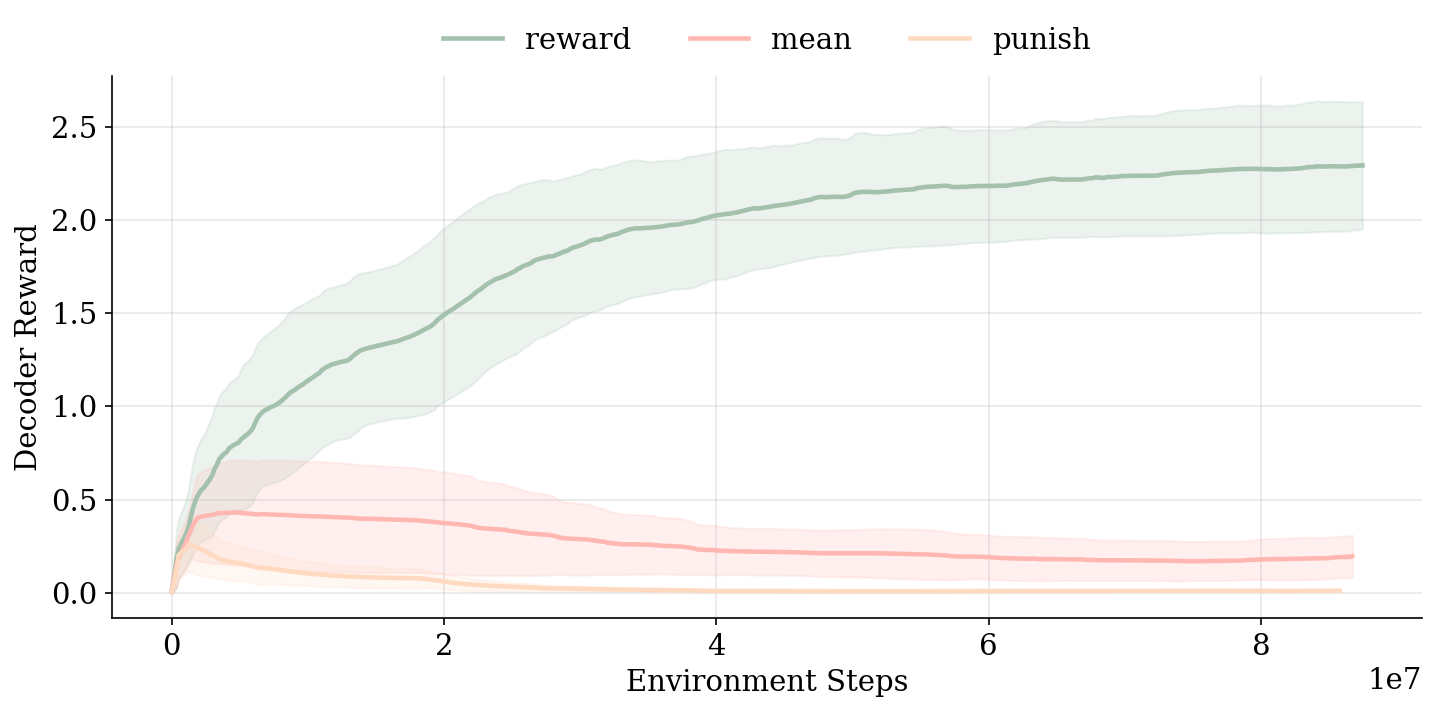

In [42]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# USER SETTINGS
# --------------------------
project_name = "xiaoxionglin-bernstein-center-freiburg/SF_distanceMetric_seperateReward3DG"   # Replace with your project
group_key = "encoder_reward_method"              # Config parameter to group runs by
metric = "train/decoder_rewards"               # Metric to plot
step_col = "train/env_steps"              # Step column in W&B
n_frac = 0.35                   # Keep first 25% of data
smooth_window = 50              # Rolling mean window


# --------------------------
# Initialize W&B API
# --------------------------
api = wandb.Api()

# Get all runs
all_runs = api.runs(project_name)

# Detect all group values for the chosen config key
groups = sorted(set(run.config.get(group_key) for run in all_runs if run.config.get(group_key) is not None))
print("Detected groups:", groups)

# --------------------------
# Smoothing function
# --------------------------
def rolling_smooth(series, window=50):
    return series.rolling(window=window, min_periods=1).mean()

# --------------------------
# Plot
# --------------------------
fig, ax = plt.subplots(1, 1, figsize=(10,5), dpi=150)
# colors = plt.cm.tab10.colors

for gi, group_name in enumerate(groups):
    color = colors[gi % len(colors)]
    
    # Fetch runs for this group
    runs = api.runs(project_name, filters={f"config.{group_key}": group_name})
    resampled_runs = []

    for run in runs:
        df = run.history(keys=[metric, step_col]).dropna()
        if len(df) < 10:
            continue
        
        # Keep only first n% of steps
        max_step = df[step_col].max()
        df = df[df[step_col] <= max_step * n_frac]
        if len(df) < 5:
            continue
        
        # Smooth
        df[metric + "_smooth"] = rolling_smooth(df[metric], window=smooth_window)

        # Resample to common axis
        num_points = 500
        steps = np.linspace(df[step_col].min(), df[step_col].max(), num_points)
        values = np.interp(steps, df[step_col], df[metric + "_smooth"])
        resampled_runs.append(values)

    if not resampled_runs:
        continue

    resampled_runs = np.array(resampled_runs)
    mean_curve = resampled_runs.mean(axis=0)
    std_curve = resampled_runs.std(axis=0)

    # Plot mean + shaded std
    ax.plot(steps, mean_curve, color=color, label=group_name)
    ax.fill_between(steps, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.2)

# Labels & title
# ax.set_title(f"{metric.capitalize()} Across Groups ({int(n_frac*100)}% of steps)")
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Decoder Reward")

# Legend outside
handles = ["reward", "mean", "punish"]

from matplotlib.lines import Line2D
intercept_handles = [
    Line2D([0], [0], color=colors[j], label=f"{handles[j]}")
    for j in range(len(handles))
]

ax.legend(
    handles=intercept_handles,
    # title="Groups",
    frameon=False,
    bbox_to_anchor=(0.5, 1.14),
    loc="upper center",
    ncol=3, fancybox=True
)
# ax.legend(handles=intercept_handles, title="Intercept", loc='upper center', bbox_to_anchor=(0.5, 1.14),
        #   ncol=3, fancybox=True)

plt.tight_layout(rect=[0, 0, 0.98, 1])
plt.savefig("decoder_reward_convergence.svg")
plt.show()
